In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import os

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values

Y = df['fc (MPa)'].values

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

# Hyperparameter tuning for XGBoost using RandomizedSearchCV
xgb_model = xgb.XGBRegressor()

# Set the hyperparameters grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],

}

# Randomized Search CV for hyperparameter tuning
random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_grid, 
                                   n_iter=50, scoring='neg_mean_squared_error', 
                                   cv=3, verbose=1, random_state=42, n_jobs=-1)

random_search.fit(X_normal, Y_normal)

# Get the best hyperparameters
best_params = random_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Now using the best hyperparameters for the model

# Create a folder to save models if it doesn't exist
model_dir = "XGBoost_best_trial"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# DataFrame to store results
results_df = pd.DataFrame(columns=['Run', 'Test R2', 'Train R2', 'RMSE', 'MAE'])

# Run the model 100 times with different parameters and splits
for run in range(1, 101):
    print(f'Run {run}')
    
    # Split the data randomly each time
    Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=run)

    # Create the XGBoost model with the best hyperparameters
    xgb_model = xgb.XGBRegressor(**best_params)

    # Train the model
    xgb_model.fit(Xtrain, ytrain)

    # Saving the model
    model_filename = os.path.join(model_dir, f'xgb_model_run_{run}.json')
    xgb_model.save_model(model_filename)

    # Evaluate the model
    ytrain_pred = xgb_model.predict(Xtrain)
    ytest_pred = xgb_model.predict(Xtest)

    # Calculate metrics
    train_r2 = r2_score(ytrain, ytrain_pred)
    test_r2 = r2_score(ytest, ytest_pred)
    rmse = mean_squared_error(ytest, ytest_pred) ** 0.5
    mae = mean_absolute_error(ytest, ytest_pred)

    # Append results to DataFrame using concat
    results_df = pd.concat([results_df, pd.DataFrame([{
        'Run': run,
        'Test R2': test_r2,
        'Train R2': train_r2,
        'RMSE': rmse,
        'MAE': mae
    }])], ignore_index=True)

    # Print the results for this run
    print(f'Run {run}: Test R² = {test_r2}, Train R² = {train_r2}, RMSE = {rmse}, MAE = {mae}')

# Save the results to an Excel file
results_df.to_excel('XGBoost_best_trial_results.xlsx', index=False)

print("Results and models saved successfully.")


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best hyperparameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Run 1
Run 1: Test R² = 0.7748323068534362, Train R² = 0.8604500802683335, RMSE = 0.4754997339053088, MAE = 0.3489246466284103
Run 2
Run 2: Test R² = 0.7490236809640856, Train R² = 0.8629868208922487, RMSE = 0.494184221281914, MAE = 0.3650606147240321
Run 3
Run 3: Test R² = 0.7741807028060746, Train R² = 0.8577688718898124, RMSE = 0.47409991394585654, MAE = 0.35108730599965965
Run 4
Run 4: Test R² = 0.7821882602671844, Train R² = 0.8580854240493629, RMSE = 0.4496945421160753, MAE = 0.33462115230981077
Run 5
Run 5: Test R² = 0.774319303506001, Train R² = 0.8590798555645511, RMSE = 0.44653773385873163, MAE = 0.33500800765574335
Run 6
Run 6: Test R² = 0.7744881818098577, Train R² = 0.8598742288861976, RMSE = 0.4616458448596711, MAE = 0.34067649644046244
Run 7
Run 7: Test R² = 0.7865871147831779, Train R² =

Run 64: Test R² = 0.8035405963535386, Train R² = 0.8569277220784859, RMSE = 0.4435779886679865, MAE = 0.31761679362466555
Run 65
Run 65: Test R² = 0.82009094696728, Train R² = 0.8532406087360378, RMSE = 0.44024797497628376, MAE = 0.329862603697565
Run 66
Run 66: Test R² = 0.7703116688738874, Train R² = 0.8589883002809022, RMSE = 0.48521524181279224, MAE = 0.3583512332204032
Run 67
Run 67: Test R² = 0.7926743342459586, Train R² = 0.8579083391089624, RMSE = 0.4473546004204774, MAE = 0.32777697456884297
Run 68
Run 68: Test R² = 0.7692065965643788, Train R² = 0.8612269287077403, RMSE = 0.47738719160455184, MAE = 0.34940238002181034
Run 69
Run 69: Test R² = 0.7568149962360754, Train R² = 0.8622498962316862, RMSE = 0.48953481199442545, MAE = 0.34966915665699083
Run 70
Run 70: Test R² = 0.7864012038127641, Train R² = 0.8598971907283031, RMSE = 0.4809151752434903, MAE = 0.3487692871058668
Run 71
Run 71: Test R² = 0.7852855603965228, Train R² = 0.8572883721530877, RMSE = 0.4864723463054525, MAE

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import os
import time  # 导入时间模块

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values
Y = df['fc (MPa)'].values

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std
y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

# Hyperparameter tuning
xgb_model = xgb.XGBRegressor()
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}

random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_grid, 
                                   n_iter=50, scoring='neg_mean_squared_error', 
                                   cv=3, verbose=1, random_state=42, n_jobs=-1)
random_search.fit(X_normal, Y_normal)
best_params = random_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Setup saving
model_dir = "XGBoost_best_trial"
if not os.path.exists(model_dir): os.makedirs(model_dir)

# DataFrame to store results (增加 Execution_Time_s 列)
results_df = pd.DataFrame(columns=['Run', 'Test R2', 'Train R2', 'RMSE', 'MAE', 'Execution_Time_s'])

# Run the model 100 times
for run in range(1, 101):
    # 开始计时
    start_time = time.time()
    
    # Split
    Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=run)

    # Train
    xgb_model = xgb.XGBRegressor(**best_params)
    xgb_model.fit(Xtrain, ytrain)

    # Predict
    ytrain_pred = xgb_model.predict(Xtrain)
    ytest_pred = xgb_model.predict(Xtest)
    
    # 结束计时
    end_time = time.time()
    elapsed = end_time - start_time

    # Calculate metrics
    train_r2 = r2_score(ytrain, ytrain_pred)
    test_r2 = r2_score(ytest, ytest_pred)
    rmse = mean_squared_error(ytest, ytest_pred) ** 0.5
    mae = mean_absolute_error(ytest, ytest_pred)

    # Save model
    model_filename = os.path.join(model_dir, f'xgb_model_run_{run}.json')
    xgb_model.save_model(model_filename)

    # Append results
    results_df = pd.concat([results_df, pd.DataFrame([{
        'Run': run, 'Test R2': test_r2, 'Train R2': train_r2, 
        'RMSE': rmse, 'MAE': mae, 'Execution_Time_s': elapsed
    }])], ignore_index=True)

    print(f'Run {run}: Time={elapsed:.4f}s, Test R²={test_r2:.4f}')

# Save results
results_df.to_excel('XGBoost_best_trial_results.xlsx', index=False)
print(f"所有运行结束。平均单次运行时间: {results_df['Execution_Time_s'].mean():.4f} 秒")
print("Results and models saved successfully.")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best hyperparameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Run 1: Time=28.0824s, Test R²=0.7748
Run 2: Time=26.4788s, Test R²=0.7490
Run 3: Time=29.1409s, Test R²=0.7742
Run 4: Time=8.9450s, Test R²=0.7822
Run 5: Time=2.0543s, Test R²=0.7743
Run 6: Time=1.3340s, Test R²=0.7745
Run 7: Time=1.2035s, Test R²=0.7866
Run 8: Time=0.9692s, Test R²=0.7806
Run 9: Time=1.0285s, Test R²=0.7631
Run 10: Time=1.0135s, Test R²=0.7875
Run 11: Time=0.9882s, Test R²=0.7884
Run 12: Time=0.8435s, Test R²=0.7860
Run 13: Time=0.8303s, Test R²=0.8028
Run 14: Time=0.8438s, Test R²=0.7354
Run 15: Time=0.8288s, Test R²=0.7286
Run 16: Time=0.8347s, Test R²=0.8025
Run 17: Time=0.8391s, Test R²=0.7630
Run 18: Time=0.8323s, Test R²=0.7644
Run 19: Time=0.8342s, Test R²=0.7679
Run 20: Time=0.8354s, Test R²=0.7993
Run 21: Time=0.8402s, Test R²=0.7662
Run 22: Time=0.8292s, Test R²=0.7812
Run 2

In [1]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

# Define features
features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 
            'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 'VOID', 
            'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']

# Encode categorical variables if needed
# If 'PC_TYPE' is categorical, consider using:
# df = pd.get_dummies(df, columns=['PC_TYPE'], drop_first=True)

X = df[features].values
y = df['fc (MPa)'].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
Xtrain, Xtest, ytrain, ytest = train_test_split(X_scaled, y, train_size=0.85, random_state=1)

# Convert Xtrain and Xtest back to DataFrames with proper column names
Xtrain_df = pd.DataFrame(Xtrain, columns=features)
Xtest_df = pd.DataFrame(Xtest, columns=features)

# Load the saved XGBoost model from JSON
model_filename = 'XGBoost_best_trial/xgb_model_run_42.json'
rf_model = xgb.XGBRegressor()
rf_model.load_model(model_filename)

# Perform SHAP analysis
explainer = shap.TreeExplainer(rf_model)  # Use TreeExplainer for tree-based models
shap_values = explainer.shap_values(Xtest_df)  # Calculate SHAP values for the test data

# Optionally, you can visualize the SHAP values
# shap.summary_plot(shap_values, Xtest_df)


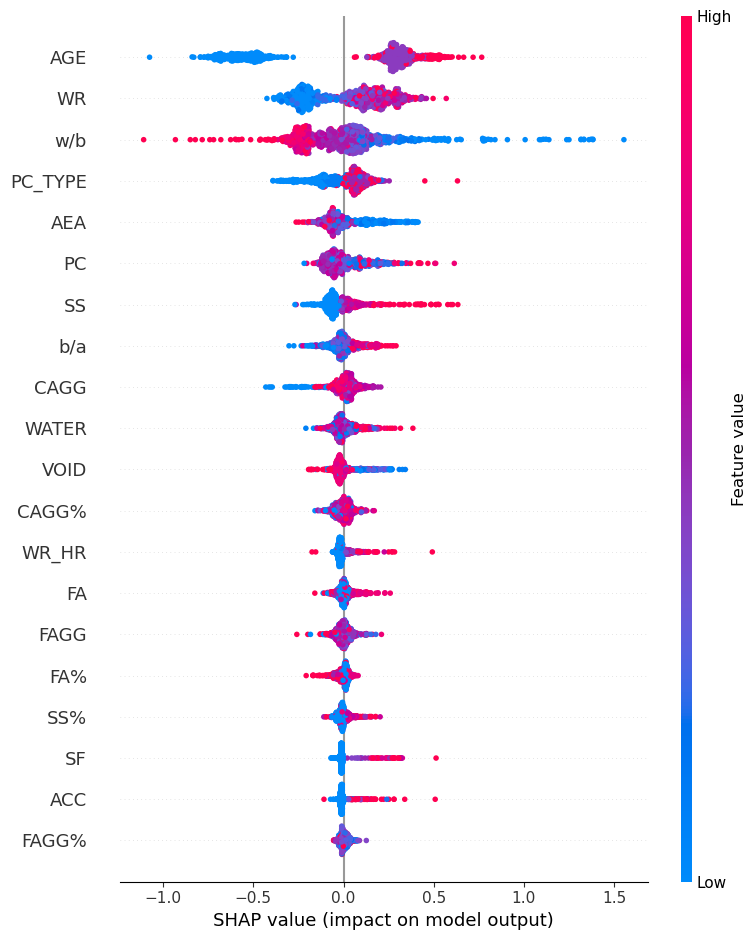

In [2]:
import matplotlib.pyplot as plt
shap.initjs()
shap.summary_plot(shap_values, Xtest_df.values, feature_names=features, show=False)  # Use Xtest_df.values
plt.savefig('XGB_summary_plot.png', bbox_inches='tight', dpi=300)  # Save the plot

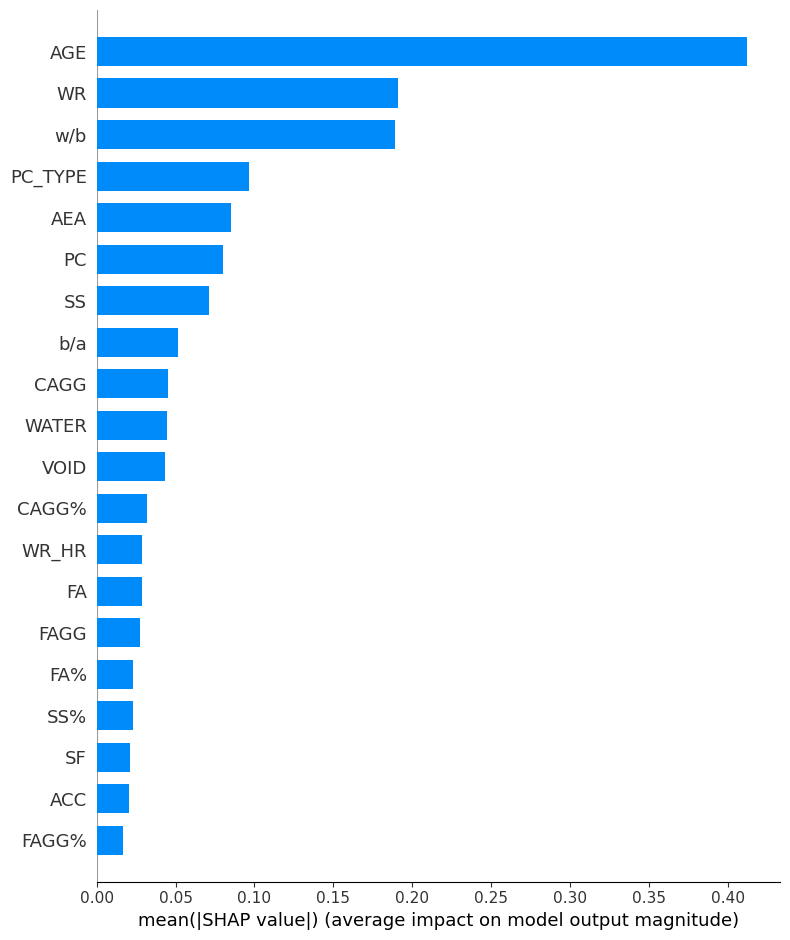

In [3]:
shap.summary_plot(shap_values, Xtest_df.values, feature_names=features, plot_type='bar', show=False)  # Use Xtest_df.values
plt.savefig('XGB_bar_plot.png', bbox_inches='tight', dpi=300)  # Save the plot

# shap.summary_plot(shap_values, Xtest_tensor.cpu().numpy(), feature_names=features, plot_type="bar", show=False)
# plt.savefig('KINN_bar_plot.png', bbox_inches='tight', dpi=300)  # You can change the filename and format as needed